In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("clean_noshows.csv")

df.head()


,gender,Age,Scholarship,hypertension,Diabetes,Alcoholism,handicap,sms_received,days_between,appointment_dayofweek,is_monday,has_chronic_condition,no_show
0,0,62,False,True,False,False,False,False,0,4,0,1,0
1,1,56,False,False,False,False,False,False,0,4,0,0,0
2,0,62,False,False,False,False,False,False,0,4,0,0,0
3,0,8,False,False,False,False,False,False,0,4,0,0,0
4,0,56,False,True,True,False,False,False,0,4,0,1,0


In [3]:
X = df.drop(columns=["no_show"])
y = df["no_show"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [4]:
### Logisitc Regression (Weak)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.86      0.69      0.77     21327
           1       0.32      0.56      0.40      5420

    accuracy                           0.67     26747
   macro avg       0.59      0.63      0.59     26747
weighted avg       0.75      0.67      0.70     26747

ROC-AUC: 0.6653091286152699


In [5]:
### Random Forest (Strong)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.90      0.58      0.70     21327
           1       0.31      0.75      0.44      5420

    accuracy                           0.61     26747
   macro avg       0.61      0.66      0.57     26747
weighted avg       0.78      0.61      0.65     26747

ROC-AUC: 0.726336122272462


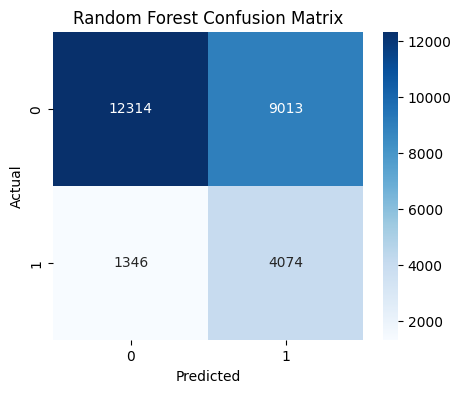

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [7]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


days_between             0.656651
Age                      0.186545
sms_received             0.045577
appointment_dayofweek    0.034908
gender                   0.017180
Scholarship              0.011598
handicap                 0.009576
Alcoholism               0.009575
hypertension             0.007926
is_monday                0.007285
Diabetes                 0.007244
has_chronic_condition    0.005934
dtype: float64

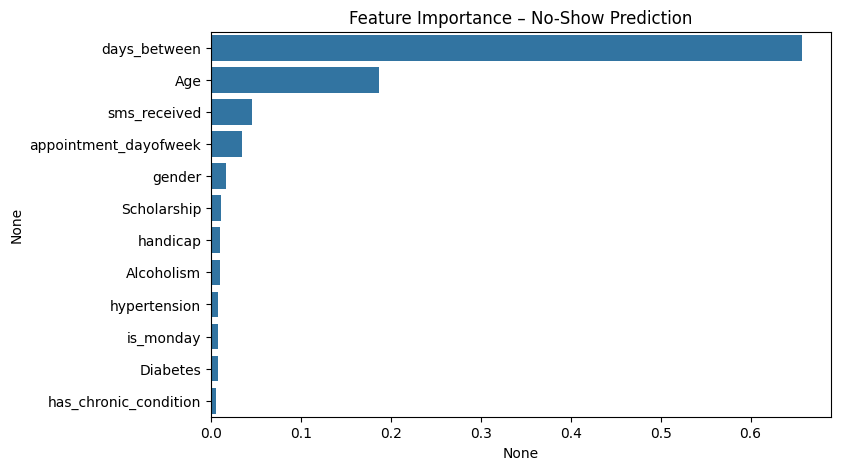

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance – No-Show Prediction")
plt.show()


In [9]:
df["risk_score"] = rf_model.predict_proba(X)[:, 1]

df.to_csv("model_scored_noshows.csv", index=False)
